## Importing the required libraries

In [1]:
# 1️⃣ Désinstaller les versions actuelles
!pip uninstall -y transformers huggingface_hub peft

# 2️⃣ Réinstaller des versions stables et compatibles entre elles
!pip install -q transformers==4.43.3 huggingface_hub==0.23.5 peft==0.3.0 --no-cache-dir


Found existing installation: transformers 4.53.3
Uninstalling transformers-4.53.3:
  Successfully uninstalled transformers-4.53.3
Found existing installation: huggingface-hub 1.0.0rc2
Uninstalling huggingface-hub-1.0.0rc2:
  Successfully uninstalled huggingface-hub-1.0.0rc2
Found existing installation: peft 0.16.0
Uninstalling peft-0.16.0:
  Successfully uninstalled peft-0.16.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 139.3 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 402.8/402.8 kB 323.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 234.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 260.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 153.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 156.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import Dataset
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import transformers, huggingface_hub, peft
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print (device)

2025-10-15 12:23:27.920581: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760531008.153996      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760531008.221093      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


cuda


## Ingesting the data and preprocessing

In [3]:
# Ingesting the data
df_tweet = pd.read_csv("/kaggle/input/sentiment140/training.1600000.processed.noemoticon.csv",
                       encoding='ISO-8859-1')
# Vérification
print(df_tweet.head())
# Resetting the column name
df_tweet.loc[-1] = df_tweet.columns
df_tweet = df_tweet.sort_index().reset_index(drop = True)

   0  1467810369  Mon Apr 06 22:19:45 PDT 2009  NO_QUERY _TheSpecialOne_  \
0  0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY   scotthamilton   
1  0  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY        mattycus   
2  0  1467811184  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY         ElleCTF   
3  0  1467811193  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY          Karoli   
4  0  1467811372  Mon Apr 06 22:20:00 PDT 2009  NO_QUERY        joy_wolf   

  @switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D  
0  is upset that he can't update his Facebook by ...                                                                   
1  @Kenichan I dived many times for the ball. Man...                                                                   
2    my whole body feels itchy and like its on fire                                                                    
3  @nationwideclass no, it's not behaving at all....           

In [4]:
# Renaming the columns
df_tweet.columns = ['target', 'id', 'date', 'query_status', 'user_name', 'tweet']

# Selecting the required columns only for the LLM
df_tweet = df_tweet[['id', 'target', 'tweet']].copy()

In [5]:
# Convert labels: 0 (Negative) -> 0, 2 (Neutral) -> 2, 4 (Positive) -> 1
df_tweet["target"] = df_tweet["target"].replace({0: 0, 2: 2, 4: 1})

# Changing the datatype
df_tweet['target'] = df_tweet['target'].astype(int)

In [6]:
# Taking 200k Tweets to train the model
df_1 = df_tweet.loc[df_tweet['target'] == 1, :][0:100000]
df_0 = df_tweet.loc[df_tweet['target'] == 0, :][0:100000]
df_tweet = pd.concat([df_1, df_0])

In [7]:
df_tweet.target.value_counts()

target
1    100000
0    100000
Name: count, dtype: int64

In [8]:
df_tweet.head()

,id,target,tweet
800000,1467822272,1,I LOVE @Health4UandPets u guys r the best!!
800001,1467822273,1,im meeting up with one of my besties tonight! ...
800002,1467822283,1,"@DaRealSunisaKim Thanks for the Twitter add, S..."
800003,1467822287,1,Being sick can be really cheap when it hurts t...
800004,1467822293,1,@LovesBrooklyn2 he has that effect on everyone


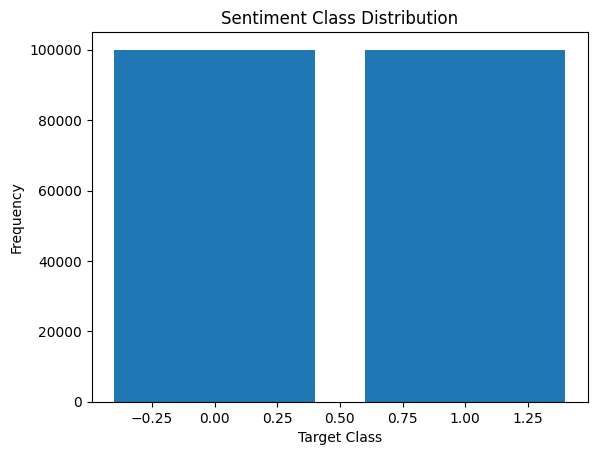

In [9]:
# Count the frequency of each target class
target_counts = df_tweet['target'].value_counts()

# Plot the bar chart
plt.bar(target_counts.index, target_counts.values)
plt.xlabel('Target Class')
plt.ylabel('Frequency')
plt.title('Sentiment Class Distribution')
plt.show()

In [10]:
# Initialize StratifiedShuffleSplit with 1 split, 70% for train, 30% for validation
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=42)

# Split the dataset while preserving the label distribution
for train_index, val_index in sss.split(df_tweet["tweet"], df_tweet["target"]):
    # Convert the pandas Series to lists for tokenization
    train_texts, val_texts = df_tweet["tweet"].iloc[train_index].tolist(), df_tweet["tweet"].iloc[val_index].tolist()
    train_labels, val_labels = df_tweet["target"].iloc[train_index].tolist(), df_tweet["target"].iloc[val_index].tolist()

# Print the lengths to check
print(len(train_texts))
print(len(val_texts))

160000
40000


## Training LLM - distilbert

In [11]:
# ✅ Correction du bug Hugging Face sur Kaggle

!pip uninstall -y transformers huggingface_hub
!pip install -q transformers==4.43.3 huggingface_hub==0.23.5 --no-cache-dir
!rm -rf ~/.cache/huggingface






Found existing installation: transformers 4.43.3
Uninstalling transformers-4.43.3:
  Successfully uninstalled transformers-4.43.3
Found existing installation: huggingface-hub 0.23.5
Uninstalling huggingface-hub-0.23.5:
  Successfully uninstalled huggingface-hub-0.23.5
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 157.9 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 402.8/402.8 kB 289.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.1.1 requires huggingface-hub>=0.24.0, but you have huggingface-hub 0.23.5 which is incompatible.
datasets 4.1.1 requires pyarrow>=21.0.0, but you have pyarrow 19.0.1 which is incompatible.
diffusers 0.34.0 requires huggingface-hub>=0.27.0, but you have huggingface-hub 0.23.5 which is incompatible.

In [12]:

# Initialize tokenizer
from transformers import AutoTokenizer
model_name ="distilbert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Tokenizing the texts
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=128)

# Checking tokenized output
train_encodings[0]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

Encoding(num_tokens=118, attributes=[ids, type_ids, tokens, offsets, attention_mask, special_tokens_mask, overflowing])

In [13]:
# Creating the training dataset using the encoded inputs, attention masks, and labels
train_dataset = Dataset.from_dict({
    "input_ids": train_encodings["input_ids"], 
    "attention_mask": train_encodings["attention_mask"], # The attention masks for the training data
    "labels": train_labels
})

# Creating the validation dataset using the encoded inputs, attention masks, and labels
val_dataset = Dataset.from_dict({
    "input_ids": val_encodings["input_ids"], 
    "attention_mask": val_encodings["attention_mask"], # The attention masks for the training data
    "labels": val_labels
})

In [14]:
# Loading the pre-trained model
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels = 2)
model.to(device)

model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(119547, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): MultiHeadSelfAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [15]:
# Setting up the training parameters and initializing the Trainer to handle model training and evaluation
training_args = TrainingArguments(
    output_dir="/kaggle/working/",
    run_name="sentiment_classification_run",
    eval_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=500,
    push_to_hub=False,
    report_to="none",
    save_total_limit=2,
    load_best_model_at_end=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
   
)

In [16]:
# Training the model
trainer.train()

/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,0.397100,0.403569
2,0.295800,0.389808


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


TrainOutput(global_step=10000, training_loss=0.36933736572265624, metrics={'train_runtime': 3248.8778, 'train_samples_per_second': 98.496, 'train_steps_per_second': 3.078, 'total_flos': 9769470650880000.0, 'train_loss': 0.36933736572265624, 'epoch': 2.0})

## Saving the model

In [17]:
trainer.save_model("./sentiment_model")
tokenizer.save_pretrained("./sentiment_model")

('./sentiment_model/tokenizer_config.json',
 './sentiment_model/special_tokens_map.json',
 './sentiment_model/vocab.txt',
 './sentiment_model/added_tokens.json',
 './sentiment_model/tokenizer.json')

## Evaluating the model

In [18]:
# Make predictions on the validation set
predictions = trainer.predict(val_dataset)

# Get the predicted labels (by taking the argmax of the logits)
predicted_labels = predictions.predictions.argmax(axis=-1)

/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


In [19]:
# Calculating the accuracy
accuracy = accuracy_score(val_labels, predicted_labels)
print(f"Accuracy: {accuracy*100:.2f} %")

# Generating detailed classification report
report = classification_report(val_labels, predicted_labels, target_names=["Negative", "Positive"])
print(report)

Accuracy: 83.44 %
              precision    recall  f1-score   support

    Negative       0.83      0.84      0.83     20000
    Positive       0.84      0.83      0.83     20000

    accuracy                           0.83     40000
   macro avg       0.83      0.83      0.83     40000
weighted avg       0.83      0.83      0.83     40000



In [20]:
import torch

def predict_texts(model, tokenizer, texts, max_length=128):
    """
    Prédit les labels pour une liste de textes avec un modèle Transformers.
    
    Args:
        model: AutoModelForSequenceClassification entraîné ou chargé.
        tokenizer: AutoTokenizer correspondant au modèle.
        texts: liste de strings à prédire.
        max_length: longueur maximale pour la tokenization.
        
    Returns:
        predictions: liste des labels prédites (int)
        probs: liste des probabilités softmax pour chaque classe
    """
    model.eval()  # mettre le modèle en mode évaluation
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    # Tokenization
    encodings = tokenizer(
        texts,
        truncation=True,
        padding=True,
        max_length=max_length,
        return_tensors="pt"
    )
    
    # Déplacer les tenseurs sur le bon device
    input_ids = encodings["input_ids"].to(device)
    attention_mask = encodings["attention_mask"].to(device)
    
    # Forward pass
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits  # shape [batch_size, num_labels]
    
    # Softmax pour obtenir les probabilités
    probs = torch.softmax(logits, dim=-1)
    
    # Label prédit = argmax
    predictions = torch.argmax(probs, dim=-1)
    
    return predictions.cpu().numpy(), probs.cpu().numpy()


In [24]:
texts_to_predict = [
    "Ilovethis movie!",
    "This is the worst product I have ever bought.",
    "idont think iseasytoworkthis",
    "This movie was a complete waste of time.",

"I am really disappointed with the service.",

"The food was cold and tasteless.",
    "j'aime jouer avec les amis",
    "le cielest noir,et les rues sont fairepeur"
]

preds, probs = predict_texts(model, tokenizer, texts_to_predict)

for t, p, pr in zip(texts_to_predict, preds, probs):
    print(f"Texte : {t}")
    print(f"Label prédit : {p}, Probabilités : {pr}\n")


Texte : Ilovethis movie!
Label prédit : 1, Probabilités : [0.00476283 0.9952371 ]

Texte : This is the worst product I have ever bought.
Label prédit : 0, Probabilités : [0.99501306 0.00498691]

Texte : idont think iseasytoworkthis
Label prédit : 1, Probabilités : [0.39313307 0.6068669 ]

Texte : This movie was a complete waste of time.
Label prédit : 0, Probabilités : [0.85788643 0.14211355]

Texte : I am really disappointed with the service.
Label prédit : 0, Probabilités : [0.9963347  0.00366531]

Texte : The food was cold and tasteless.
Label prédit : 0, Probabilités : [0.98033464 0.0196653 ]

Texte : j'aime jouer avec les amis
Label prédit : 1, Probabilités : [0.06351078 0.9364892 ]

Texte : le cielest noir,et les rues sont fairepeur
Label prédit : 0, Probabilités : [0.78936785 0.21063219]

